<a href="https://colab.research.google.com/github/priyalu-tech/priyalu-tech.github.io/blob/main/cie_4(KMeans).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
df = pd.read_csv("/content/Mall_Customers.csv")
# Display dataset
print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [2]:
# 2. Data preprocessing
# Check missing values
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64


In [3]:
# Remove missing values
df = df.dropna()

In [4]:
# Select required features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [6]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

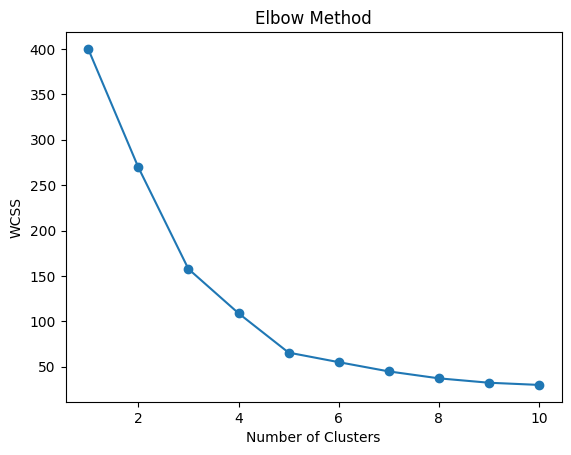

In [7]:
# 3. Find optimal number of clusters using Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [8]:
# 4. Train K-Means with optimal clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster number to dataset
df['Cluster'] = y_kmeans

print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


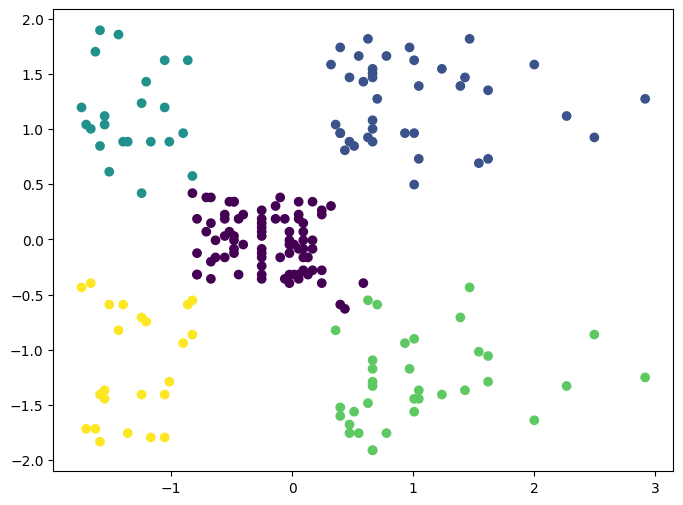

In [9]:
# 5. Visualize the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_kmeans
)

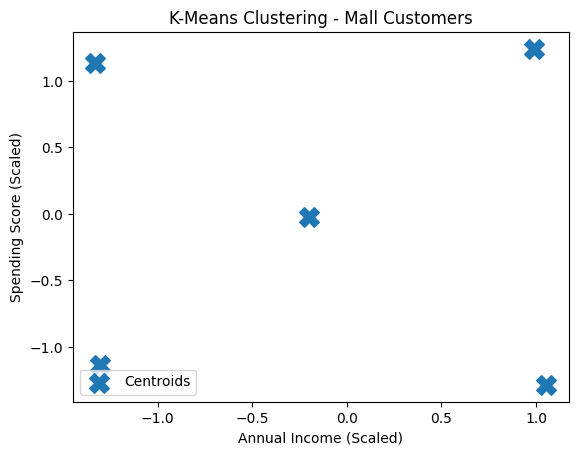

In [10]:
# Plot centroids
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("K-Means Clustering - Mall Customers")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()

The K-Means clustering algorithm groups mall customers based on their Annual Income and Spending Score.

Cluster 1: Customers with low annual income and low spending score.
Cluster 2: Customers with low annual income but high spending score.
Cluster 3: Customers with high annual income and low spending score.
Cluster 4: Customers with high annual income and high spending score.
The clusters help the mall understand different customer groups and their purchasing behaviour.
Customers with high income and high spending scores can be considered important target customers for premium offers.
The clustering makes it easier for the mall to plan marketing strategies, discounts, and personalized offers.